In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns 
from sklearn.preprocessing import LabelEncoder

In [2]:
data=pd.read_excel("predection_data.xlsx")

In [3]:
print(data.head())

  customer_id  gender  age married        state  number_of_referrals  \
0   19877-DEL    Male   35      No        Delhi                    7   
1   58353-MAH  Female   45     Yes  Maharashtra                   14   
2   25063-WES    Male   51      No  West Bengal                    4   
3   59787-KAR    Male   79      No    Karnataka                    3   
4   28544-TAM  Female   80      No   Tamil Nadu                    3   

   tenure_in_months value_deal phone_service multiple_lines  ...  \
0                27        NaN           Yes             No  ...   
1                13        NaN           Yes            Yes  ...   
2                35     Deal 5           Yes             No  ...   
3                21     Deal 4           Yes             No  ...   
4                 8        NaN           Yes             No  ...   

    payment_method monthly_charge total_charges total_refunds  \
0      Credit Card           65.6        593.30          0.00   
1      Credit Card          

In [4]:
# Drop columns that won't be used for prediction
data = data.drop(['customer_id', 'churn_category', 'churn_reason'], axis=1)


In [5]:
# List of columns to be label encoded

# Remove customer_status from encoding list
columns_to_encode = [

    'gender', 'married', 'state', 'value_deal', 'phone_service', 'multiple_lines',

    'internet_service', 'internet_type', 'online_security', 'online_backup',

    'device_protection_plan', 'premium_support', 'streaming_tv', 'streaming_movies',

    'streaming_music', 'unlimited_data', 'contract', 'paperless_billing','customer_status',

    'payment_method'

]

# Encode categorical columns
label_encoders = {}

for column in columns_to_encode:

    label_encoders[column] = LabelEncoder()

    data[column] = label_encoders[column].fit_transform(data[column])



In [6]:
data['customer_status']

0       1
1       1
2       0
3       0
4       0
       ..
6002    0
6003    1
6004    0
6005    1
6006    1
Name: customer_status, Length: 6007, dtype: int64

In [7]:
data.tail()

,gender,age,married,state,number_of_referrals,tenure_in_months,value_deal,phone_service,multiple_lines,internet_service,...,contract,paperless_billing,payment_method,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,customer_status
6002,0,41,0,19,6,33,5,1,1,1,...,0,1,1,74.40,896.75,0.0,0,37.96,934.71,0
6003,1,51,1,6,0,19,0,0,0,1,...,2,0,1,45.25,3139.80,0.0,0,0.00,3139.80,1
6004,0,65,1,10,14,25,5,1,1,1,...,0,1,0,74.95,2869.85,0.0,0,599.64,3469.49,0
6005,1,23,0,13,2,10,5,1,1,1,...,1,1,1,70.15,4480.70,0.0,0,2107.52,6588.22,1
6006,1,73,0,17,13,21,5,1,0,1,...,2,1,0,96.85,1235.55,0.0,0,346.84,1582.39,1


In [8]:
# Split data into features and target

X = data.drop('customer_status', axis=1)

y = data['customer_status']

In [11]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
y_train

5632    1
5838    1
2348    1
5332    1
5661    1
       ..
3772    0
5191    1
5226    1
5390    1
860     1
Name: customer_status, Length: 4805, dtype: int64

In [13]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

 

# Train the model

rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [14]:
#Evaluate Model

# Make predictions

y_pred = rf_model.predict(X_test)


In [15]:
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix
accur = accuracy_score(y_test, y_pred)

In [16]:
print("accuracy",accur)

accuracy 0.8469217970049917


In [21]:
# Evaluate the model

print("Confusion Matrix:")

print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")

print(classification_report(y_test, y_pred))

Confusion Matrix:
[[241 115]
 [ 61 785]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.68      0.73       356
           1       0.87      0.93      0.90       846

    accuracy                           0.85      1202
   macro avg       0.84      0.80      0.82      1202
weighted avg       0.85      0.85      0.85      1202



In [19]:
# Feature Selection using Feature Importance

importances = rf_model.feature_importances_

indices = np.argsort(importances)[::-1]

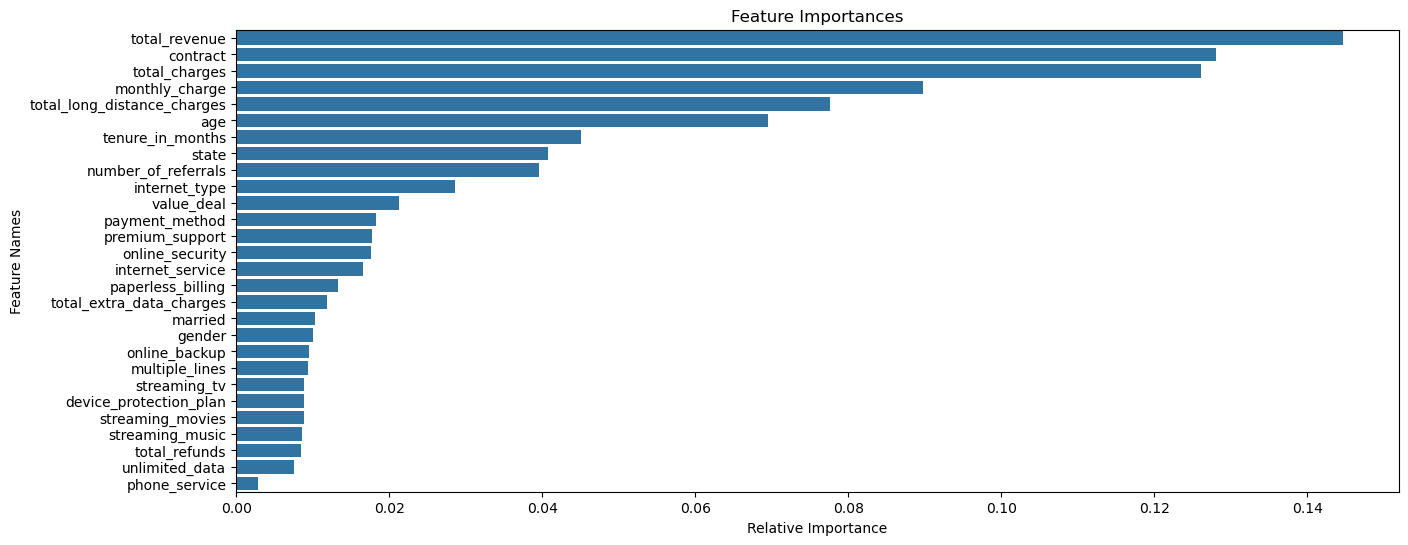

In [20]:
# Plot the feature importances

plt.figure(figsize=(15, 6))

sns.barplot(x=importances[indices], y=X.columns[indices])

plt.title('Feature Importances')

plt.xlabel('Relative Importance')

plt.ylabel('Feature Names')

plt.show()

### Use Model for Prediction on New Data

In [27]:
new_data=pd.read_csv("VIEW_data.csv")

In [28]:
new_data

,customer_id,gender,age,married,state,number_of_referrals,tenure_in_months,value_deal,phone_service,multiple_lines,...,payment_method,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,customer_status,churn_category,churn_reason
0,93520-GUJ,Female,67,No,Gujarat,13,19,Deal 5,Yes,Yes,...,Bank Withdrawal,72.10,72.10,0.0,0,7.77,79.87,Joined,Others,Others
1,57256-BIH,Female,18,No,Bihar,9,7,NaN,Yes,No,...,Credit Card,19.85,57.20,0.0,0,9.36,66.56,Joined,Others,Others
2,72357-MAD,Female,53,No,Madhya Pradesh,14,12,Deal 5,Yes,No,...,Credit Card,44.30,44.30,0.0,0,42.95,87.25,Joined,Others,Others
3,66612-KAR,Female,58,Yes,Karnataka,11,18,NaN,Yes,No,...,Credit Card,19.95,58.00,0.0,0,8.07,66.07,Joined,Others,Others
4,22119-WES,Male,31,Yes,West Bengal,5,5,NaN,Yes,No,...,Credit Card,20.05,33.70,0.0,0,3.62,37.32,Joined,Others,Others
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,31412-HAR,Female,81,Yes,Haryana,14,29,NaN,Yes,No,...,Bank Withdrawal,19.20,37.20,0.0,0,14.06,51.26,Joined,Others,Others
407,54997-UTT,Female,55,No,Uttar Pradesh,7,23,NaN,Yes,No,...,Credit Card,44.00,44.00,0.0,0,26.15,70.15,Joined,Others,Others
408,56728-RAJ,Male,40,No,Rajasthan,0,1,NaN,Yes,No,...,Credit Card,45.60,45.60,0.0,0,37.44,83.04,Joined,Others,Others
409,47624-TAM,Female,62,Yes,Tamil Nadu,7,29,NaN,Yes,No,...,Mailed Check,-5.00,189.10,0.0,0,100.59,289.69,Joined,Others,Others


In [29]:

# Retain the original DataFrame to preserve unencoded columns

original_data = new_data.copy()

 

# Retain the Customer_ID column

customer_ids = new_data['customer_id']

 

# Drop columns that won't be used for prediction in the encoded DataFrame

new_data = new_data.drop(['customer_id', 'customer_status', 'churn_category', 'churn_reason'], axis=1)

 

# Encode categorical variables using the saved label encoders

for column in new_data.select_dtypes(include=['object']).columns:

    new_data[column] = label_encoders[column].transform(new_data[column])

 

# Make predictions

new_predictions = rf_model.predict(new_data)

 

# Add predictions to the original DataFrame

original_data['Customer_Status_Predicted'] = new_predictions

 

# Filter the DataFrame to include only records predicted as "Churned"

original_data = original_data[original_data['Customer_Status_Predicted'] == 0]

In [31]:
original_data

,customer_id,gender,age,married,state,number_of_referrals,tenure_in_months,value_deal,phone_service,multiple_lines,...,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,customer_status,churn_category,churn_reason,Customer_Status_Predicted
0,93520-GUJ,Female,67,No,Gujarat,13,19,Deal 5,Yes,Yes,...,72.10,72.1,0.0,0,7.77,79.87,Joined,Others,Others,0
1,57256-BIH,Female,18,No,Bihar,9,7,NaN,Yes,No,...,19.85,57.2,0.0,0,9.36,66.56,Joined,Others,Others,0
2,72357-MAD,Female,53,No,Madhya Pradesh,14,12,Deal 5,Yes,No,...,44.30,44.3,0.0,0,42.95,87.25,Joined,Others,Others,0
3,66612-KAR,Female,58,Yes,Karnataka,11,18,NaN,Yes,No,...,19.95,58.0,0.0,0,8.07,66.07,Joined,Others,Others,0
4,22119-WES,Male,31,Yes,West Bengal,5,5,NaN,Yes,No,...,20.05,33.7,0.0,0,3.62,37.32,Joined,Others,Others,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,21065-HAR,Male,27,No,Haryana,5,10,NaN,Yes,No,...,20.30,20.3,0.0,0,10.84,31.14,Joined,Others,Others,0
406,31412-HAR,Female,81,Yes,Haryana,14,29,NaN,Yes,No,...,19.20,37.2,0.0,0,14.06,51.26,Joined,Others,Others,0
407,54997-UTT,Female,55,No,Uttar Pradesh,7,23,NaN,Yes,No,...,44.00,44.0,0.0,0,26.15,70.15,Joined,Others,Others,0
408,56728-RAJ,Male,40,No,Rajasthan,0,1,NaN,Yes,No,...,45.60,45.6,0.0,0,37.44,83.04,Joined,Others,Others,0


In [37]:
# Save to CSV file
original_data.to_csv('filtered_data.csv', index=False)